## 1.使用朴素贝叶斯解决20类新闻分类

In [25]:
from sklearn.datasets import fetch_20newsgroups  # 导入sklearn中用于获取20类新闻数据集的函数

# 加载20类新闻数据集，data_home为本地缓存地址，subset='all'表示加载全部数据
newsgroups = fetch_20newsgroups(data_home='data', subset='all')
print(len(newsgroups.data))
# 输出特征和标签
print("特征（文本数据）示例：")               # 打印一条新闻文本示例
print(newsgroups.data[0])                    # 输出第一条新闻文本内容
print("\n标签示例：", newsgroups.target[0])   # 输出第一条新闻对应的标签（类别编号）
print("标签总数：", len(newsgroups.target))    # 输出数据集中所有样本的标签数量
print("类别名称：", newsgroups.target_names)   # 输出所有类别的名称列表
print("data类型：", type(newsgroups.data))     # 输出新闻数据的类型（如list）
print("target类型：", type(newsgroups.target)) # 输出标签的类型（如ndarray）
print("target最小值：", min(newsgroups.target)) # 输出标签中的最小值（类别索引最小值）
print("target最大值：", max(newsgroups.target)) # 输出标签中的最大值（类别索引最大值）



d:\Programs\Python\Python312\Lib\site-packages\sklearn\datasets\_twenty_newsgroups.py:310: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  cache = pickle.loads(uncompressed_content)


18846
特征（文本数据）示例：
From: Mamatha Devineni Ratnam <mr47+@andrew.cmu.edu>
Subject: Pens fans reactions
Organization: Post Office, Carnegie Mellon, Pittsburgh, PA
Lines: 12
NNTP-Posting-Host: po4.andrew.cmu.edu



I am sure some bashers of Pens fans are pretty confused about the lack
of any kind of posts about the recent Pens massacre of the Devils. Actually,
I am  bit puzzled too and a bit relieved. However, I am going to put an end
to non-PIttsburghers' relief with a bit of praise for the Pens. Man, they
are killing those Devils worse than I thought. Jagr just showed you why
he is much better than his regular season stats. He is also a lot
fo fun to watch in the playoffs. Bowman should let JAgr have a lot of
fun in the next couple of games since the Pens are going to beat the pulp out of Jersey anyway. I was very disappointed not to see the Islanders lose the final
regular season game.          PENS RULE!!!



标签示例： 10
标签总数： 18846
类别名称： ['alt.atheism', 'comp.graphics', 'comp.os.ms-window

In [26]:
# 数据分割及TF-IDF特征提取

from sklearn.model_selection import train_test_split        # 导入数据集划分函数
from sklearn.feature_extraction.text import TfidfVectorizer # 导入TF-IDF向量化工具

# 将原始新闻文本数据划分为训练集和测试集（25%作为测试集，随机种子为42以保证结果可复现）
X_train, X_test, y_train, y_test = train_test_split(
    newsgroups.data, newsgroups.target, test_size=0.25, random_state=42
)

# 初始化TF-IDF向量化器
vectorizer = TfidfVectorizer()

# 对训练集进行TF-IDF特征提取和向量化（生成稀疏矩阵，行数为文本数，列数为特征词数）
X_train_tfidf = vectorizer.fit_transform(X_train)
print(type(vectorizer))

# 输出处理后训练集的特征数（即词汇表的大小）
print("处理后的特征数：", X_train_tfidf.shape)

# 输出词汇表中部分特征名（100000到100009的词项）
print(vectorizer.get_feature_names_out()[100000:100010])

<class 'sklearn.feature_extraction.text.TfidfVectorizer'>
处理后的特征数： (14134, 146060)
['o_uv' 'o_wcp_' 'o_yd' 'oa' 'oa0' 'oa13' 'oa2' 'oa3' 'oa44o' 'oa4no']


In [27]:
# 导入朴素贝叶斯分类器和评估指标
from sklearn.naive_bayes import MultinomialNB  # 多项式朴素贝叶斯（Multinomial Naive Bayes）
from sklearn.metrics import classification_report, accuracy_score  # 分类报告和准确率评估指标

# 步骤1：对测试集进行TF-IDF向量化处理（Feature Extraction/特征提取）
# 注意：这里使用transform()而不是fit_transform()，因为要使用训练集学到的词汇表和权重
X_test_tfidf = vectorizer.transform(X_test)  # 返回值类型：scipy.sparse.csr_matrix（稀疏矩阵）
# transform()：只进行转换，不重新学习词汇表和权重（使用训练集的参数）

# 步骤2：创建并训练朴素贝叶斯分类器（Model Training/模型训练）
nb = MultinomialNB(alpha=1)  # 返回值类型：MultinomialNB对象
# MultinomialNB：多项式朴素贝叶斯，适用于文本分类
# alpha=1：拉普拉斯平滑参数（Laplace Smoothing），防止概率为0的情况
# alpha越大，平滑程度越高，模型越保守

# 训练模型：使用训练集的TF-IDF特征和标签进行训练
nb.fit(X_train_tfidf, y_train)  # 返回值类型：MultinomialNB对象（已训练）
# fit()方法会：
# 1. 计算每个类别的先验概率（Prior Probability）
# 2. 计算每个特征在每个类别下的条件概率（Conditional Probability）

# 步骤3：使用训练好的模型进行预测（Prediction/预测）
y_pred = nb.predict(X_test_tfidf)  # 返回值类型：numpy.ndarray（预测的类别标签数组）
# predict()：对测试集进行预测，返回每个样本的预测类别

# 步骤4：评估模型性能（Model Evaluation/模型评估）
# 计算准确率（Accuracy）：正确预测的样本数 / 总样本数
print("准确率：", accuracy_score(y_test, y_pred))  # 返回值类型：float（浮点数，0-1之间）
# accuracy_score()：计算准确率，返回0到1之间的值

# 输出详细的分类报告（Classification Report）
print("\n详细分类报告：\n", classification_report(y_test, y_pred, target_names=newsgroups.target_names))
# classification_report()：生成详细的分类性能报告
# 返回值类型：str（字符串格式的报告）
# 报告包含：
#   - precision（精确率/查准率）：预测为正类中实际为正类的比例
#   - recall（召回率/查全率）：实际为正类中被正确预测的比例
#   - f1-score（F1分数）：精确率和召回率的调和平均数
#   - support（支持度）：每个类别的样本数量
# target_names：类别名称列表，用于显示可读的类别名称而不是数字编号


准确率： 0.8425297113752123

详细分类报告：
                           precision    recall  f1-score   support

             alt.atheism       0.88      0.72      0.79       198
           comp.graphics       0.86      0.79      0.82       245
 comp.os.ms-windows.misc       0.88      0.83      0.85       242
comp.sys.ibm.pc.hardware       0.66      0.86      0.75       238
   comp.sys.mac.hardware       0.95      0.84      0.89       250
          comp.windows.x       0.96      0.80      0.87       260
            misc.forsale       0.96      0.66      0.78       241
               rec.autos       0.89      0.93      0.91       244
         rec.motorcycles       0.91      0.95      0.93       219
      rec.sport.baseball       0.96      0.94      0.95       261
        rec.sport.hockey       0.90      0.98      0.94       245
               sci.crypt       0.78      0.98      0.87       251
         sci.electronics       0.92      0.80      0.86       249
                 sci.med       0.97      

## 2.决策树练习并调参，从而提升准确率，随机森林练习，结合网格搜索调参，找到最佳参数模型,可以让AI帮忙调参，告诉AI你的数据集情况，然后让其帮你修改超参

In [28]:
# 导入pandas库，用于数据处理和分析
import pandas as pd  # pandas：Python数据分析库

# 步骤1：读取CSV数据文件（Data Loading/数据加载）
# 只读取指定的列，减少内存占用并提高读取速度
df = pd.read_csv("data/titanic.csv", usecols=["pclass", "sex", "age", "survived"])
# 返回值类型：pandas.DataFrame（数据框）
# usecols参数：指定要读取的列名列表
#   - "pclass"：船舱等级（Passenger Class）
#   - "sex"：性别（Gender）
#   - "age"：年龄（Age）
#   - "survived"：是否幸存（Survival Status，0=未幸存，1=幸存）

# 步骤2：查看数据的基本信息（Data Exploration/数据探索）
# 展示前5行数据，了解数据结构和内容
display(df.head())  # 返回值类型：pandas.DataFrame（在Jupyter中美观显示）
# head()方法：默认显示前5行数据，可以指定参数显示更多行，如head(10)
# display()：在Jupyter Notebook中美观地显示DataFrame，比print()更适合表格数据

# 步骤3：检查缺失值（Missing Value Detection/缺失值检测）
# 统计每列中缺失值（NaN/None）的数量
print(df.isnull().sum())  # 返回值类型：pandas.Series（每列的缺失值数量）
# isnull()：返回布尔DataFrame，True表示缺失值，False表示非缺失值
# sum()：对每列的True值求和，得到每列的缺失值数量
# 输出格式：列名 -> 缺失值数量

# 步骤4：生成数据描述性统计（Descriptive Statistics/描述性统计）
print(df.describe(include='all'))  # 返回值类型：pandas.DataFrame（统计摘要表）
# describe()：生成数据的描述性统计摘要
# include='all'：包含所有类型的列（数值型和分类型）
# 对于数值型列（如age, survived）：
#   - count：非缺失值数量
#   - mean：平均值
#   - std：标准差（Standard Deviation）
#   - min：最小值
#   - 25%：第一四分位数（25th Percentile）
#   - 50%：中位数（Median/50th Percentile）
#   - 75%：第三四分位数（75th Percentile）
#   - max：最大值
# 对于分类型列（如pclass, sex）：
#   - count：非缺失值数量
#   - unique：唯一值数量
#   - top：出现频率最高的值（Mode/众数）
#   - freq：最高频率值的出现次数


,pclass,survived,age,sex
0,1st,1,29.0000,female
1,1st,0,2.0000,female
2,1st,0,30.0000,male
3,1st,0,25.0000,female
4,1st,1,0.9167,male


pclass        0
survived      0
age         680
sex           0
dtype: int64
       pclass     survived         age   sex
count    1313  1313.000000  633.000000  1313
unique      3          NaN         NaN     2
top       3rd          NaN         NaN  male
freq      711          NaN         NaN   850
mean      NaN     0.341965   31.194181   NaN
std       NaN     0.474549   14.747525   NaN
min       NaN     0.000000    0.166700   NaN
25%       NaN     0.000000   21.000000   NaN
50%       NaN     0.000000   30.000000   NaN
75%       NaN     1.000000   41.000000   NaN
max       NaN     1.000000   71.000000   NaN


In [31]:
# ========== 数据预处理（Data Preprocessing）==========
# 目的：准备用于机器学习模型训练的特征矩阵X和标签向量y

import pandas as pd
from sklearn.impute import KNNImputer

# 步骤1：处理缺失值（Missing Value Imputation/缺失值填充）
# ✅ 修改：不再用 mean 填充 age，而是用 KNNImputer 基于特征相似性预测缺失的 age

# 1) 取出用于“预测 age”的相关特征（包含 age 本身）
age_features = df[['pclass', 'sex', 'survived', 'age']].copy()

# 2) 将分类特征 pclass、sex 转成数值（One-Hot），确保 KNNImputer 输入全是数值
#    - 注意：这里不要 drop_first=True，因为丢一列可能会损失信息（对填充不划算）
age_features_encoded = pd.get_dummies(age_features, columns=['pclass', 'sex'])

# 3) KNN 填充器：找最相近的 k 个样本，用距离加权方式预测缺失值
imputer = KNNImputer(
    n_neighbors=5,
    weights='distance'
)

# 4) 执行填充（返回 numpy.ndarray）
age_filled = imputer.fit_transform(age_features_encoded)

# 5) 写回 df['age']：找到 age 在编码后矩阵中的列索引
age_col_idx = age_features_encoded.columns.get_loc('age')
df['age'] = age_filled[:, age_col_idx]

# 步骤2：提取标签（Label Extraction/标签提取）
# 取出survived列作为目标变量（Target Variable/标签）
y = df['survived']  # 返回值类型：pandas.Series
# y：标签向量（Label Vector），包含每个样本的类别（0=未幸存，1=幸存）

# 步骤3：特征工程（Feature Engineering/特征工程）
# 对分类特征进行One-Hot编码（One-Hot Encoding/独热编码）
X = pd.get_dummies(df[['pclass', 'sex']])  # 返回值类型：pandas.DataFrame

# 将age列添加到特征矩阵X中
X['age'] = df['age']  # 返回值类型：pandas.DataFrame（修改后的X）
# age是数值型特征，不需要编码，直接使用填充后的值

# 步骤4：查看最终的特征矩阵（Feature Matrix）
X  # 返回值类型：pandas.DataFrame


,pclass_1st,pclass_2nd,pclass_3rd,sex_female,sex_male,age
0,True,False,False,True,False,29.0000
1,True,False,False,True,False,2.0000
2,True,False,False,False,True,30.0000
3,True,False,False,True,False,25.0000
4,True,False,False,False,True,0.9167
...,...,...,...,...,...,...
1308,False,False,True,False,True,25.4000
1309,False,False,True,False,True,25.4000
1310,False,False,True,False,True,25.4000
1311,False,False,True,True,False,26.0000


准确率: 0.908745247148289


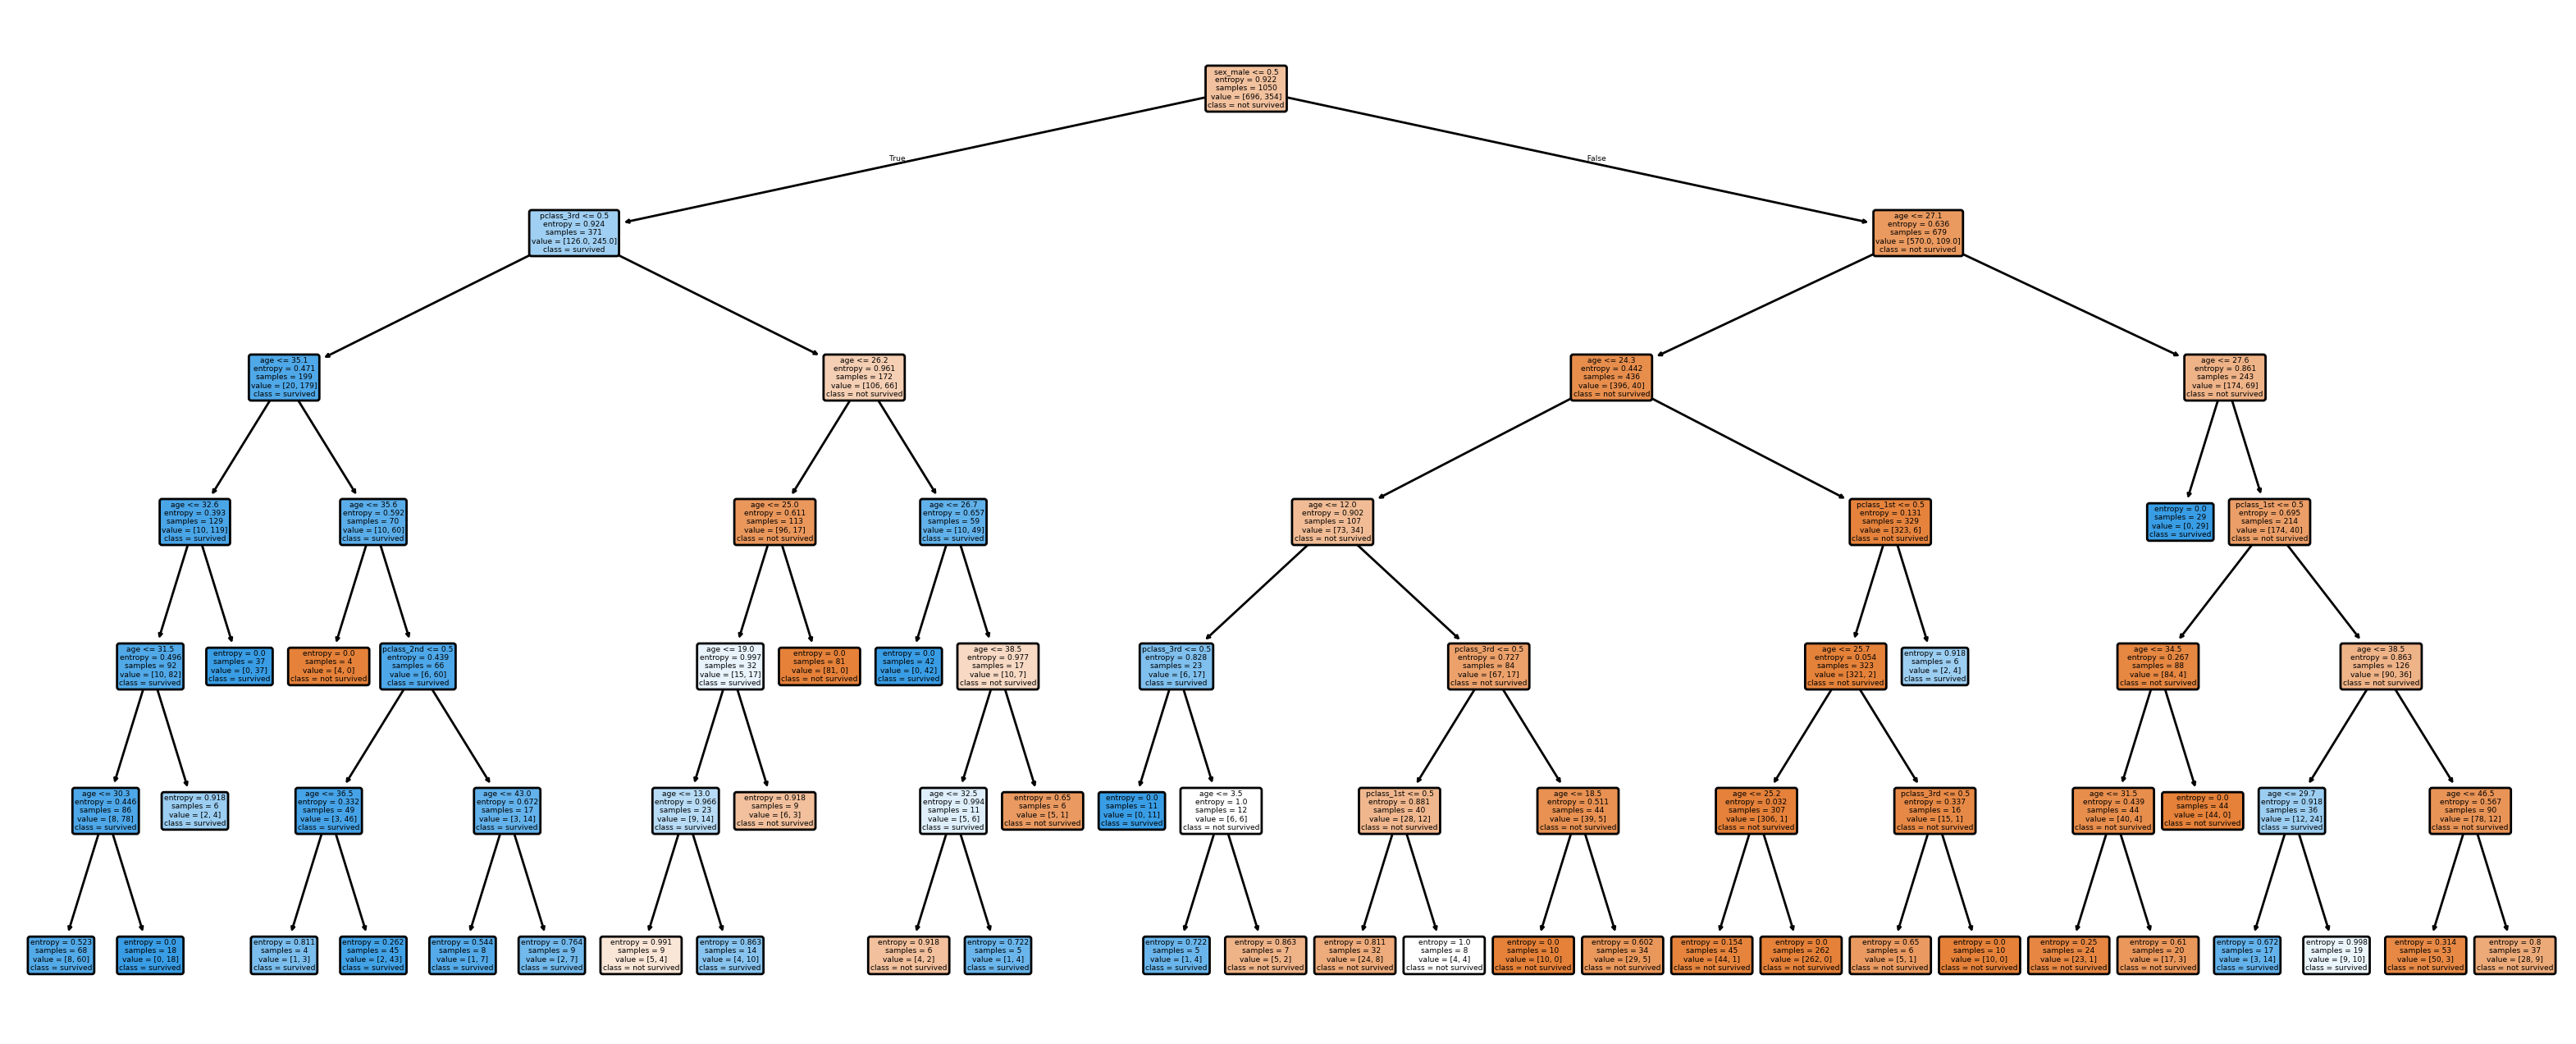

In [32]:
# ========== 决策树模型训练与可视化（Decision Tree Training & Visualization）==========
# 目的：使用决策树算法对泰坦尼克号数据进行分类，并可视化决策过程

# 导入必要的库
from sklearn.model_selection import train_test_split  # 数据集划分函数
from sklearn.tree import DecisionTreeClassifier  # 决策树分类器（Decision Tree Classifier）
from sklearn.metrics import accuracy_score, classification_report  # 评估指标：准确率和分类报告
import matplotlib.pyplot as plt  # 绘图库，用于可视化
from sklearn import tree  # sklearn的树可视化模块

# 步骤1：划分训练集与测试集（Train-Test Split/训练测试集划分）
# 将数据按8:2的比例划分为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# 返回值类型：4个pandas.Series/DataFrame（X_train, X_test, y_train, y_test）
# test_size=0.2：测试集占20%，训练集占80%
# random_state=42：随机种子，保证每次划分结果一致（可复现性）

# 步骤2：创建决策树分类器（Decision Tree Classifier）
clf = DecisionTreeClassifier(
    random_state=42,         # 随机种子（Random Seed），保证结果可复现
    max_depth=6,             # 树的最大深度（Maximum Depth），防止过拟合（Overfitting）
    min_samples_split=10,    # 内部节点再划分所需最小样本数（Minimum Samples Split）
    min_samples_leaf=4,      # 叶子节点最少样本数（Minimum Samples Leaf），避免出现只含一个样本的叶子
    criterion='entropy'      # 划分标准（Splitting Criterion），这里用信息熵（Entropy/Information Gain）
)
# 返回值类型：DecisionTreeClassifier对象
# 参数说明：
#   - max_depth：限制树的深度，防止模型过于复杂导致过拟合
#   - min_samples_split：节点必须至少有10个样本才能继续分裂
#   - min_samples_leaf：叶子节点必须至少有4个样本
#   - criterion='entropy'：使用信息熵作为划分标准（另一种选择是'gini'基尼不纯度）

# 步骤3：训练决策树模型（Model Training/模型训练）
clf.fit(X_train, y_train)  # 返回值类型：DecisionTreeClassifier对象（已训练）
# fit()方法会：
# 1. 从根节点开始，递归地选择最佳特征和划分点
# 2. 使用信息熵（Entropy）计算信息增益（Information Gain）
# 3. 选择信息增益最大的特征进行划分
# 4. 重复上述过程，直到满足停止条件（达到最大深度、样本数不足等）

# 步骤4：模型评估（Model Evaluation/模型评估）
# 使用训练好的模型对测试集进行预测
y_pred = clf.predict(X_test)  # 返回值类型：numpy.ndarray（预测的类别标签数组）
# predict()：对测试集进行预测，返回每个样本的预测类别（0或1）

# 计算准确率（Accuracy）
acc = accuracy_score(y_test, y_pred)  # 返回值类型：float（浮点数，0-1之间）
# accuracy_score()：计算准确率 = 正确预测的样本数 / 总样本数
print("准确率:", acc)

# 步骤5：可视化决策树（Decision Tree Visualization/决策树可视化）
# 创建图形对象，设置图形大小和分辨率
plt.figure(figsize=(20, 8), dpi=200)  # 返回值类型：matplotlib.figure.Figure对象
# figsize=(20, 8)：图形尺寸（宽度20英寸，高度8英寸）
# dpi=200：分辨率（Dots Per Inch），数值越大图像越清晰

# 绘制决策树图形
tree.plot_tree(clf,  # 已训练的决策树分类器对象
               feature_names=X.columns,  # 特征名称列表，用于显示特征名而不是索引
               class_names=["not survived", "survived"],  # 类别名称列表（0=未幸存，1=幸存）
               filled=True,  # 填充颜色（Filled），根据类别或值给节点着色
               rounded=True)  # 圆角矩形（Rounded），使节点更美观
# plot_tree()：绘制决策树的可视化图形
# 返回值类型：matplotlib图形对象

# 保存决策树图形为SVG格式（Scalable Vector Graphics/可缩放矢量图形）
plt.savefig('titanic.svg')  # 保存为SVG格式，矢量图，可无损缩放
# SVG格式优点：
#   - 矢量图，可无损放大缩小
#   - 文件较小
#   - 适合打印和展示


## 📊 决策树SVG图内容详解

### 决策树结构说明

生成的`titanic.svg`文件展示了完整的决策树结构，每个节点包含以下信息：

#### 1. **节点类型（Node Types）**

- **根节点（Root Node）**：树的顶部节点，包含所有训练样本
- **内部节点（Internal Node/Decision Node）**：包含划分条件的中间节点
- **叶子节点（Leaf Node/Terminal Node）**：最终的分类结果节点

#### 2. **节点信息解读**

每个节点框中通常包含以下信息：

```
特征名 <= 阈值?
├─ samples: 样本数量（该节点包含的样本总数）
├─ value: [类别0的样本数, 类别1的样本数]
├─ entropy/gini: 当前节点的熵值或基尼不纯度
└─ class: 该节点的预测类别（如果到达叶子节点）
```

**示例节点说明：**
- `sex_female <= 0.5`：判断是否为女性（0.5是One-Hot编码的阈值）
  - `samples = 1050`：该节点有1050个样本
  - `value = [600, 450]`：其中600个未幸存（类别0），450个幸存（类别1）
  - `entropy = 0.985`：当前节点的信息熵值
  - `class = not survived`：如果到达叶子节点，预测为"未幸存"

#### 3. **决策路径（Decision Path）**

从根节点到叶子节点的路径表示一个完整的决策规则：

**示例路径：**
```
根节点（所有样本）
  ↓ sex_female <= 0.5? (是否为女性)
  ├─ 是（女性）→ 继续判断其他特征
  │   ↓ age <= 30.5? (年龄是否≤30.5岁)
  │   ├─ 是 → 继续判断...
  │   └─ 否 → 继续判断...
  └─ 否（男性）→ 继续判断其他特征
      ↓ pclass_3rd <= 0.5? (是否为三等舱)
      ├─ 是（不是三等舱）→ 继续判断...
      └─ 否（是三等舱）→ 预测：not survived
```

#### 4. **颜色编码（Color Coding）**

- **节点颜色深浅**：通常表示该节点中某个类别的样本比例
  - 颜色越深：该类别样本占比越高
  - 颜色越浅：样本分布越均匀
- **不同颜色**：可能表示不同的类别（如果设置了`filled=True`）

#### 5. **关键特征识别**

通过观察决策树，可以识别出最重要的特征：
- **出现在较高层级的特征**：对分类影响更大
- **被多次使用的特征**：在多个节点中出现，说明该特征很重要
- **信息增益大的划分**：熵值下降明显的节点，说明划分效果好

#### 6. **模型解释性（Model Interpretability）**

决策树的最大优势是**可解释性强**：
- 可以清楚地看到每个预测的决策过程
- 可以理解模型为什么做出某个预测
- 可以提取出"如果-那么"规则（If-Then Rules）

**示例规则提取：**
```
IF sex_female == 1 AND age <= 30.5 AND pclass_1st == 1
THEN 预测：survived（幸存）

IF sex_female == 0 AND pclass_3rd == 1 AND age > 25.0
THEN 预测：not survived（未幸存）
```

#### 7. **过拟合检测（Overfitting Detection）**

通过观察决策树可以判断是否过拟合：
- **树太深**：如果树有很多层，可能过拟合
- **叶子节点样本数很少**：如果很多叶子节点只有1-2个样本，可能过拟合
- **训练集准确率远高于测试集**：说明模型记忆了训练数据

#### 8. **参数调优参考**

根据决策树的可视化结果，可以调整参数：
- **如果树太深**：增加`max_depth`的限制
- **如果叶子节点样本太少**：增加`min_samples_leaf`
- **如果节点分裂太频繁**：增加`min_samples_split`

### 实际应用建议

1. **特征重要性分析**：观察哪些特征在树的上层出现，这些特征最重要
2. **业务规则提取**：将决策路径转换为业务规则，用于决策支持
3. **模型优化**：根据树的复杂度调整参数，平衡准确率和可解释性
4. **异常检测**：观察哪些样本的预测路径异常，可能是异常值


In [33]:
# 统计y_train中0和1的数量，了解训练集中不同类别(存活/未存活)的样本分布
print("训练集中未存活(0)人数:", (y_train == 0).sum())
print("训练集中存活(1)人数:", (y_train == 1).sum())

# 用groupby分析不同性别与存活的对应关系
# 先通过X_train的索引，还原按顺序对应的sex标签
sex_train = df.loc[X_train.index, 'sex'] # 还原训练集中每个样本的性别
survived_train = y_train                 # 训练集中每个样本是否存活（目标标签）
print(X_train.index)

# 组装为DataFrame，方便按性别和存活状态分组分析
sex_survived = pd.DataFrame({
    'sex': sex_train,
    'survived': survived_train
})

# 用groupby对sex和survived两列分组，然后计算每组数量
# unstack用于将survived这一分组变量变成列，便于观察性别与存活的对应数量
grouped = sex_survived.groupby(['sex', 'survived']).size().unstack(fill_value=0)

print("\n按性别分组的存活情况：")
print(type(grouped))
print(grouped)





训练集中未存活(0)人数: 696
训练集中存活(1)人数: 354
Index([ 140,  903,  363,  199,  994,  297,  879,   10,  147,  354,
       ...
        330, 1238,  466,  121, 1044, 1095, 1130, 1294,  860, 1126],
      dtype='int64', length=1050)

按性别分组的存活情况：
<class 'pandas.core.frame.DataFrame'>
survived    0    1
sex               
female    126  245
male      570  109


In [34]:
from sklearn.ensemble import RandomForestClassifier

# 创建随机森林分类器
rf_clf = RandomForestClassifier(
    n_estimators=500,    # 默认100棵树
    criterion='gini', 
    max_depth=5,
    random_state=42
)
rf_clf.fit(X_train, y_train)

# 预测并评估
rf_y_pred = rf_clf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_y_pred)
print("随机森林准确率:", rf_acc)


随机森林准确率: 0.8973384030418251


In [36]:
# 针对泰坦尼克号数据集优化超参数网格，适配csv数据实际情况
# 根据数据分析，泰坦尼克特征数量有限、类别型特征已独热编码，超参可适当聚焦如下组合

param_grid: dict = {
    'n_estimators': [500, 1000, 2000],       # 森林数目适当增加，强调模型稳定性
    'max_depth': [5, 8, 10, None],           # 深度增加，尝试更复杂的关系，但None仅作限范围补充
    'min_samples_split': [2, 5, 10],         # 浅层树易过拟合，适当增加划分所需最小样本
    'min_samples_leaf': [1, 3, 5],           # 叶节点最小样本数稍提升
    'max_features': [1.0, 'sqrt', 'log2'],      # 直接尝试全部特征、sqrt与log2，特征维度有限时不用None
    'criterion': ['entropy'],                   # entropy在泰坦尼克任务上通常略优于gini
    'random_state': [42]                        # 固定随机种子，保证可复现
}

from sklearn.model_selection import GridSearchCV

# 网格搜索使用分层交叉验证，保证标签均衡
from sklearn.model_selection import StratifiedKFold
cv: StratifiedKFold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

grid_search: GridSearchCV = GridSearchCV(
    estimator=RandomForestClassifier(),
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# GridSearchCV.fit() 的返回值类型为 self（即GridSearchCV对象本身）
fit_result: GridSearchCV = grid_search.fit(X_train, y_train)

# best_params_ 的返回值类型为 dict
print("最佳参数:", grid_search.best_params_)
# best_score_ 的返回值类型为 float
print("交叉验证最佳准确率: {:.4f}".format(grid_search.best_score_))

# best_params_ 为 dict， best_max_features 的类型取决于搜索空间，为 str、float 或 None
best_max_features = grid_search.best_params_['max_features']
if best_max_features == 1.0 or best_max_features is None or best_max_features == 'auto':
    n_features_used: int = X_train.shape[1]
elif best_max_features == 'sqrt':
    import math
    n_features_used: int = int(round(X_train.shape[1]**0.5))
elif best_max_features == 'log2':
    import math
    n_features_used: int = int(round(math.log2(X_train.shape[1])))
else:
    n_features_used: int = best_max_features
print(f"最优模型使用的特征数: {n_features_used}")

# best_estimator_ 的返回值类型为 RandomForestClassifier
best_rf: RandomForestClassifier = grid_search.best_estimator_
# score() 的返回值类型为 float
test_acc: float = best_rf.score(X_test, y_test)
print("最优模型在测试集上的准确率: {:.4f}".format(test_acc))


Fitting 10 folds for each of 324 candidates, totalling 3240 fits
最佳参数: {'criterion': 'entropy', 'max_depth': 8, 'max_features': 1.0, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 500, 'random_state': 42}
交叉验证最佳准确率: 0.9019
最优模型使用的特征数: 6
最优模型在测试集上的准确率: 0.9087
